In [1]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from pathlib import Path
from collections import Counter
from PIL import Image
import pandas as pd


In [4]:
dataset_path = Path("/content/drive/My Drive/projet covid radiographie pulmonaire/imagerie")

In [5]:
records = []
sizes = []
corrupted_files = []
class_counts = {}
mode_counts = Counter()

In [6]:
def mean_intensity(img):
    arr = np.array(img.convert("L"))
    return arr.mean()

def contrast(img):
    arr = np.array(img.convert("L"))
    return arr.std()

In [7]:
import os

# List contents of My Drive to help locate the dataset
print("Contenu de '/content/drive/My Drive':")
for item in os.listdir('/content/drive/My Drive'):
    print(f"- {item}")

# Optionally, you can list contents of a specific folder if you know its name, e.g.:
# print("\nContenu de '/content/drive/My Drive/votre_dossier_parent_du_dataset':")
# for item in os.listdir('/content/drive/My Drive/votre_dossier_parent_du_dataset'):
#     print(f"- {item}")

Contenu de '/content/drive/My Drive':
- CV.gdoc
- CV Merveil pdf.gdoc
- Saved from Chrome (1)
- MEDA_Presentation.pdf
- Classroom
- MyPeopleDoc est un coffre-fort électronique personnel vous permettant de recevoir et de partager vos documents en toute sécurité.
- card_UlFMQTFZUThsMm9wU2k3eGwzc25tZz09.pdf
- Copie de Template - Rapport exploration des données (2).gsheet
- Projets_méthodologie_rapports.gdoc
- Template - Rapport exploration des données.gsheet
- Copie de Template - Rapport exploration des données (1).gsheet
- Copie de Template - Rapport exploration des données.pdf
- Copie de Template - Rapport exploration des données.gsheet
- dataset_summary.csv
- Exportation Gemini 21 juin 2026 à 22:34:07 UTC+2.gdoc
- Exportation Gemini 21 juin 2026 à 23:10:45 UTC+2.gdoc
- Colab Notebooks
- projet covid radiographie pulmonaire
- Untitled Folder
- kaggle
- .ipynb_checkpoints
- datasets.pul
- train_test
- models
- covid_chest_xray_model_augmented.h5
- covid_chest_xray_model_augmen

In [8]:
records = []
sizes = []
corrupted_files = []
class_counts = {}
mode_counts = Counter()

# Nous allons itérer directement sur les fichiers dans dataset_path
# et déduire la classe du nom du fichier.

# Détecter les classes uniques à partir des noms de fichiers
# En supposant que les noms de fichiers commencent par 'COVID-' ou 'Normal-'

# Utilisation d'un ensemble pour stocker les noms de classes uniques trouvés
unique_classes = set()
for img_path in dataset_path.glob("*.png"):
    filename = img_path.name
    if filename.startswith("COVID-"):
        unique_classes.add("COVID")
    elif filename.startswith("Normal-"):
        unique_classes.add("Normal")

classes = list(unique_classes)
print(f"Classes détectées : {classes}\n")

# Maintenant, itérer sur tous les fichiers PNG dans le répertoire du dataset
for img_path in dataset_path.glob("*.png"):
    filename = img_path.name
    cls = None
    if filename.startswith("COVID-"):
        cls = "COVID"
    elif filename.startswith("Normal-"):
        cls = "Normal"

    if cls is None: # Ignorer les fichiers qui ne correspondent à aucune classe connue
        continue

    if cls not in class_counts:
        class_counts[cls] = 0

    try:
        with Image.open(img_path) as img:

            width, height = img.size
            mode = img.mode

            # features visuelles
            intensity = mean_intensity(img)
            cont = contrast(img)

            sizes.append((width, height))
            mode_counts[mode] += 1

            records.append({
                "class": cls,
                "filename": img_path.name,
                "width": width,
                "height": height,
                "mode": mode,
                "mean_intensity": intensity,
                "contrast": cont,
                "filepath": str(img_path)
            })

            class_counts[cls] += 1

    except Exception:
        corrupted_files.append(str(img_path))

Classes détectées : ['Normal', 'COVID']



In [9]:
print(f"Contenu de '{dataset_path}':")
try:
    for item in dataset_path.iterdir():
        print(f"- {item.name} (type: {'dossier' if item.is_dir() else 'fichier'})")
except FileNotFoundError:
    print(f"Le répertoire '{dataset_path}' n'a pas été trouvé. Vérifiez le chemin.")

Contenu de '/content/drive/My Drive/projet covid radiographie pulmonaire/imagerie':
- Normal-9117.png (type: fichier)
- Normal-9150.png (type: fichier)
- Normal-9092.png (type: fichier)
- Normal-9084.png (type: fichier)
- Normal-9078.png (type: fichier)
- Normal-9083.png (type: fichier)
- Normal-911.png (type: fichier)
- Normal-9085.png (type: fichier)
- Normal-9114.png (type: fichier)
- Normal-914.png (type: fichier)
- Normal-9102.png (type: fichier)
- Normal-9110.png (type: fichier)
- Normal-9121.png (type: fichier)
- Normal-9122.png (type: fichier)
- Normal-9112.png (type: fichier)
- Normal-9079.png (type: fichier)
- Normal-9093.png (type: fichier)
- Normal-9118.png (type: fichier)
- Normal-9087.png (type: fichier)
- Normal-9099.png (type: fichier)
- Normal-9107.png (type: fichier)
- Normal-9125.png (type: fichier)
- Normal-9094.png (type: fichier)
- Normal-9146.png (type: fichier)
- Normal-91.png (type: fichier)
- Normal-9082.png (type: fichier)
- Normal-9127.png (type: fichier)
- 

In [10]:
import os

# List contents of My Drive to help locate the dataset
print("Contenu de '/content/drive/My Drive':")
for item in os.listdir('/content/drive/My Drive'):
    print(f"- {item}")

# Optionally, you can list contents of a specific folder if you know its name, e.g.:
# print("\nContenu de '/content/drive/My Drive/votre_dossier_parent_du_dataset':")
# for item in os.listdir('/content/drive/My Drive/votre_dossier_parent_du_dataset'):
#     print(f"- {item}")

Contenu de '/content/drive/My Drive':
- CV.gdoc
- CV Merveil pdf.gdoc
- Saved from Chrome (1)
- MEDA_Presentation.pdf
- Classroom
- MyPeopleDoc est un coffre-fort électronique personnel vous permettant de recevoir et de partager vos documents en toute sécurité.
- card_UlFMQTFZUThsMm9wU2k3eGwzc25tZz09.pdf
- Copie de Template - Rapport exploration des données (2).gsheet
- Projets_méthodologie_rapports.gdoc
- Template - Rapport exploration des données.gsheet
- Copie de Template - Rapport exploration des données (1).gsheet
- Copie de Template - Rapport exploration des données.pdf
- Copie de Template - Rapport exploration des données.gsheet
- dataset_summary.csv
- Exportation Gemini 21 juin 2026 à 22:34:07 UTC+2.gdoc
- Exportation Gemini 21 juin 2026 à 23:10:45 UTC+2.gdoc
- Colab Notebooks
- projet covid radiographie pulmonaire
- Untitled Folder
- kaggle
- .ipynb_checkpoints
- datasets.pul
- train_test
- models
- covid_chest_xray_model_augmented.h5
- covid_chest_xray_model_augmen

In [11]:
dataset_path = Path("/gdrive/My Drive/votre_chemin_correct_vers/COVID-19_Radiography_Dataset")

In [12]:
print("\n" + "=" * 50)
print("STATISTIQUES GENERALES")
print("=" * 50)

df = pd.DataFrame(records)

print(f"Nombre total d'images : {len(df)}")
print(f"Nombre de classes : {len(class_counts)}")


STATISTIQUES GENERALES
Nombre total d'images : 13808
Nombre de classes : 2


In [13]:
import os

# List contents of the 'projet covid radiographie pulmonaire' directory
print("Contenu de '/content/drive/My Drive/projet covid radiographie pulmonaire':")
try:
    for item in os.listdir('/content/drive/My Drive/projet covid radiographie pulmonaire'):
        print(f"- {item}")
except FileNotFoundError:
    print("Le répertoire 'projet covid radiographie pulmonaire' n'a pas été trouvé à cet emplacement. Vérifiez le chemin.")

Contenu de '/content/drive/My Drive/projet covid radiographie pulmonaire':
- dataset_summary.csv
- imagerie
- colab_temp_test_preprocessing
- colab_temp_test_preprocessing_processed
- test.csv
- train.csv
- validation.csv


In [14]:
dataset_path = Path("/content/drive/My Drive/projet covid radiographie pulmonaire/NOM_EXACT_DU_DOSSIER_DU_DATASET")

In [15]:
print("\nDistribution des classes :")

for cls, count in class_counts.items():
    pct = 100 * count / len(df)
    print(f"{cls:<15} : {count:>6} images ({pct:.2f} %)")


Distribution des classes :
Normal          :  10192 images (73.81 %)
COVID           :   3616 images (26.19 %)


In [16]:
print("\nDimensions des images")

print(f"Largeur min  : {df['width'].min()}")
print(f"Largeur max  : {df['width'].max()}")
print(f"Largeur moy  : {df['width'].mean():.2f}")

print(f"Hauteur min  : {df['height'].min()}")
print(f"Hauteur max  : {df['height'].max()}")
print(f"Hauteur moy  : {df['height'].mean():.2f}")


Dimensions des images
Largeur min  : 299
Largeur max  : 299
Largeur moy  : 299.00
Hauteur min  : 299
Hauteur max  : 299
Hauteur moy  : 299.00


In [17]:
print("\nDistribution des modes (canaux) :")
for mode, count in mode_counts.items():
    print(f"{mode:<10} : {count} images")


Distribution des modes (canaux) :
L          : 13808 images


In [18]:
print("\nTop 10 des dimensions les plus fréquentes")

size_counter = Counter(sizes)

for size, count in size_counter.most_common(10):
    print(f"{size} -> {count} images")


Top 10 des dimensions les plus fréquentes
(299, 299) -> 13808 images


In [19]:
print("\nFichiers corrompus")

if corrupted_files:
    print(f"{len(corrupted_files)} fichiers problématiques")
else:
    print("Aucun fichier corrompu détecté")


Fichiers corrompus
Aucun fichier corrompu détecté


In [20]:
print("\n" + "=" * 50)
print("STATISTIQUES PAR CLASSE")
print("=" * 50)

class_stats = (
    df.groupby("class")
      .agg(
          nb_images=("filename", "count"),
          largeur_moy=("width", "mean"),
          hauteur_moy=("height", "mean")
      )
)

print(class_stats)


STATISTIQUES PAR CLASSE
        nb_images  largeur_moy  hauteur_moy
class                                      
COVID        3616        299.0        299.0
Normal      10192        299.0        299.0


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random

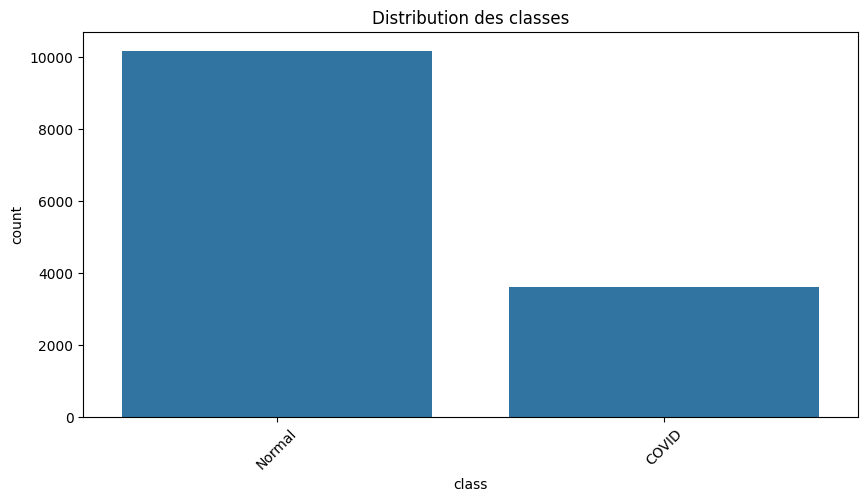

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="class", order=df["class"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution des classes")
plt.show()

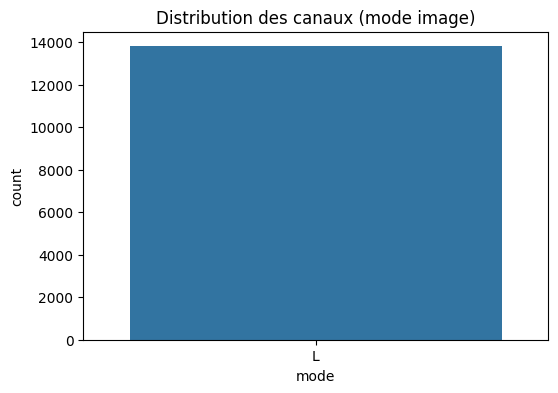

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="mode")
plt.title("Distribution des canaux (mode image)")
plt.show()

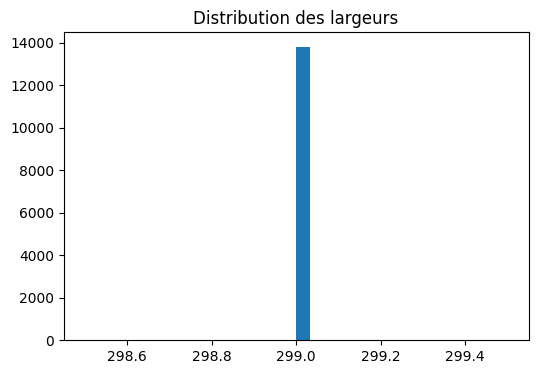

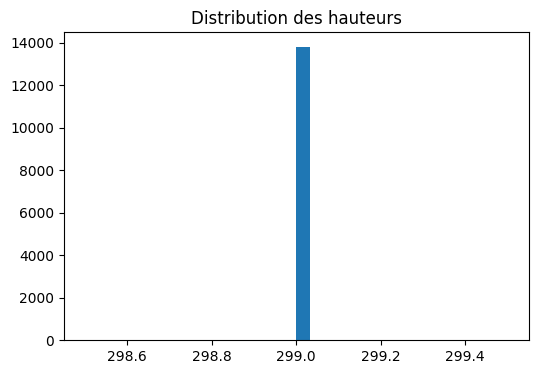

In [24]:
plt.figure(figsize=(6,4))
plt.hist(df["width"], bins=30)
plt.title("Distribution des largeurs")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["height"], bins=30)
plt.title("Distribution des hauteurs")
plt.show()

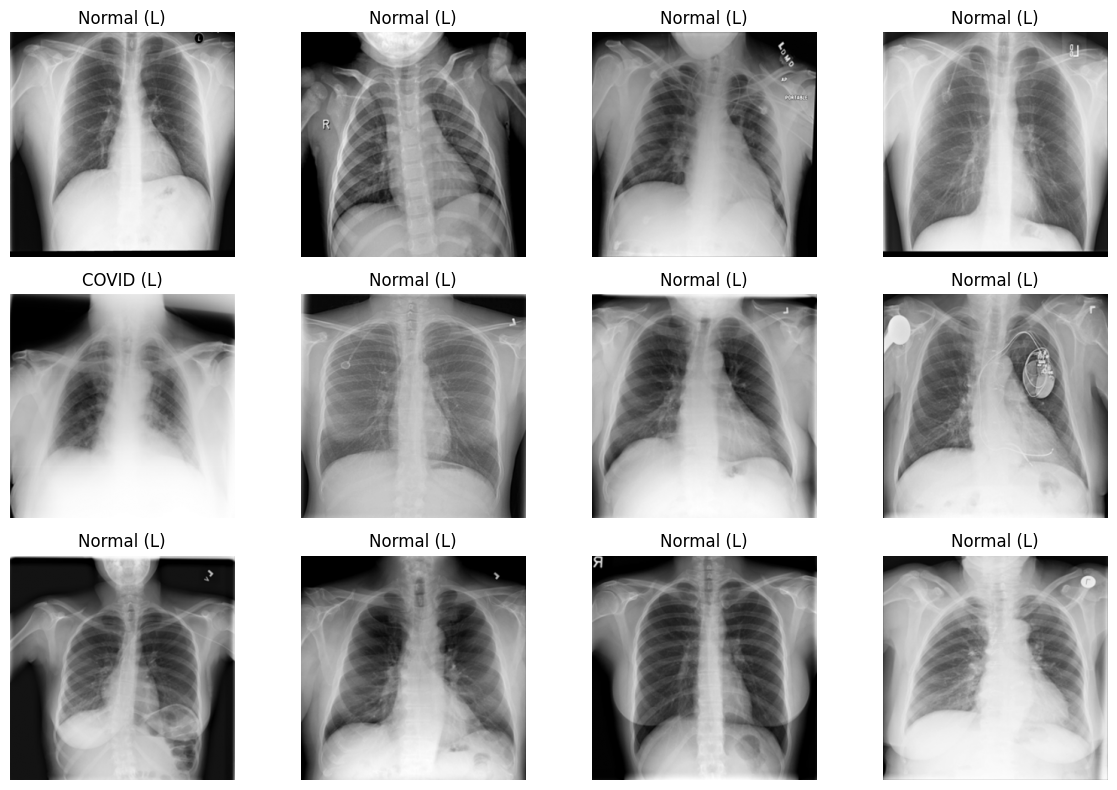

In [25]:
fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for ax in axes.flat:

    row = df.sample(1).iloc[0]
    # Utilisation du chemin d'accès complet et correct déjà stocké dans le DataFrame
    img_path = Path(row["filepath"])

    img = Image.open(img_path)

    ax.imshow(img, cmap="gray" if img.mode == "L" else None)
    ax.set_title(f"{row['class']} ({row['mode']})")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

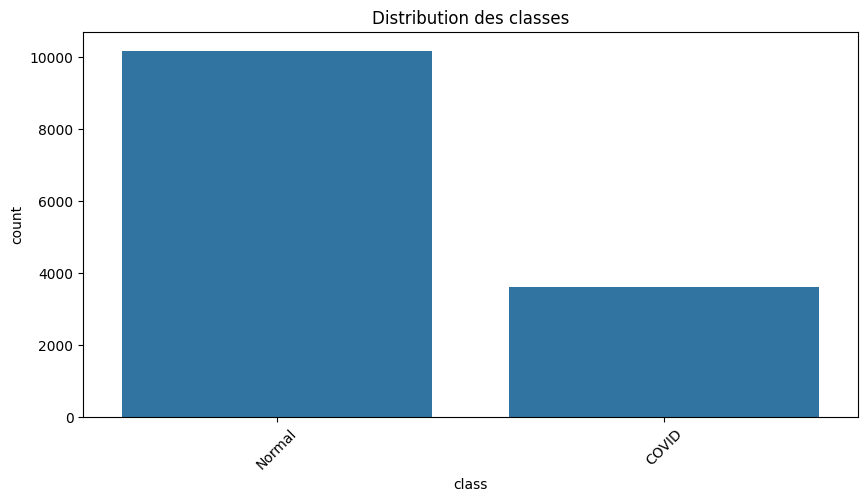

In [27]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="class", order=df["class"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution des classes")
plt.show()

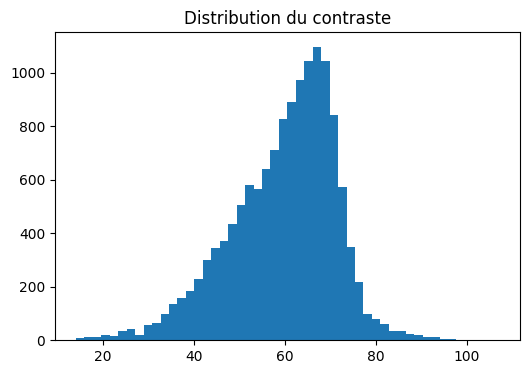

In [28]:
plt.figure(figsize=(6,4))
plt.hist(df["contrast"], bins=50)
plt.title("Distribution du contraste")
plt.show()

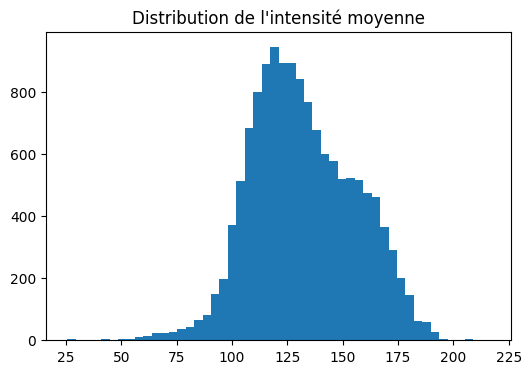

In [29]:
plt.figure(figsize=(6,4))
plt.hist(df["mean_intensity"], bins=50)
plt.title("Distribution de l'intensité moyenne")
plt.show()


IMAGES EXTRÊMES - CONTRASTE FAIBLE


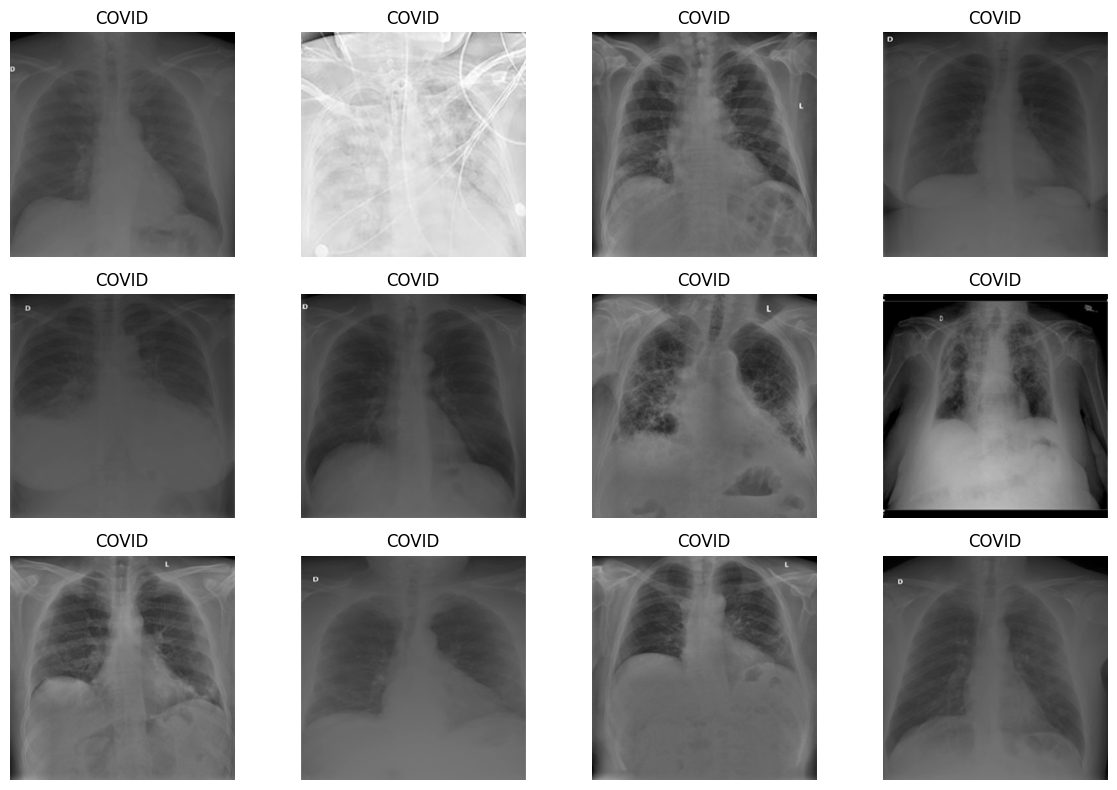

In [30]:
print("\nIMAGES EXTRÊMES - CONTRASTE FAIBLE")

low_contrast = df.nsmallest(12, "contrast")

fig, axes = plt.subplots(3,4, figsize=(12,8))

for ax, (_, row) in zip(axes.flat, low_contrast.iterrows()):
    # Utilisation du chemin d'accès complet et correct déjà stocké dans le DataFrame
    img_path = Path(row["filepath"])
    img = Image.open(img_path)

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row['class']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

IMAGES EXTRÊMES (INTENSITÉ FAIBLE / SOMBRE)


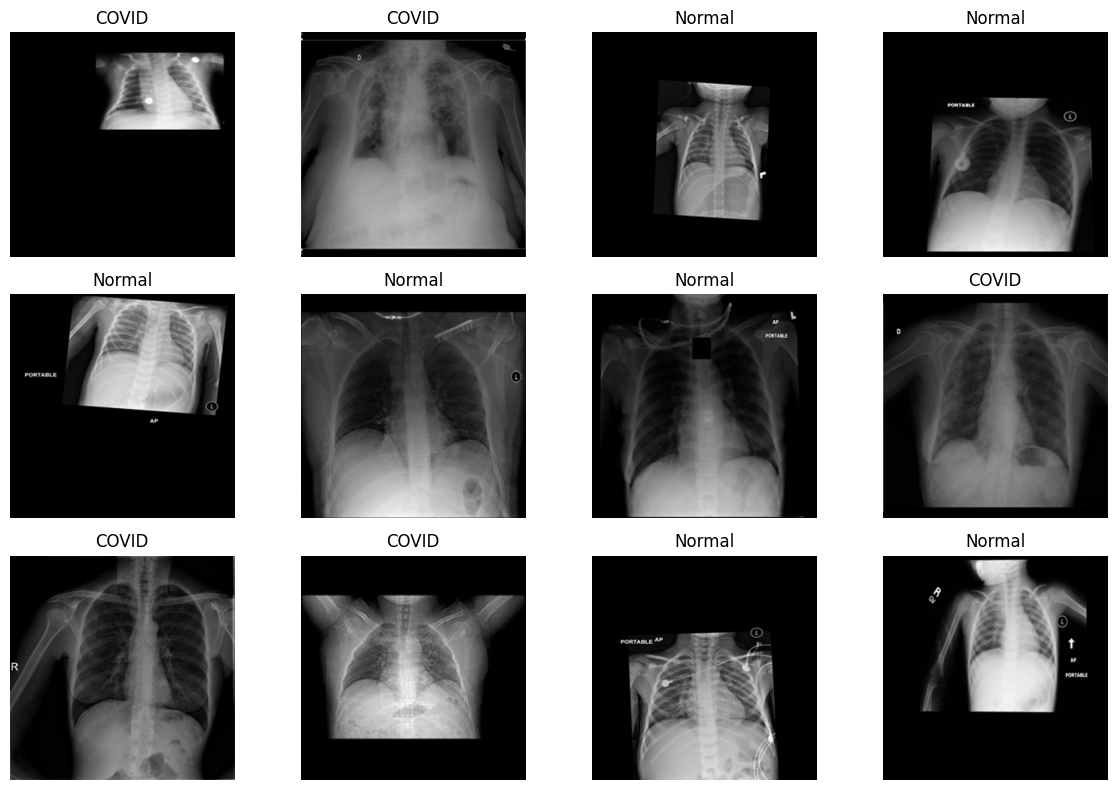

In [31]:
print("IMAGES EXTRÊMES (INTENSITÉ FAIBLE / SOMBRE)")

dark = df.nsmallest(12, "mean_intensity")

fig, axes = plt.subplots(3,4, figsize=(12,8))

for ax, (_, row) in zip(axes.flat, dark.iterrows()):
    # Utilisation du chemin d'accès complet et correct déjà stocké dans le DataFrame
    img_path = Path(row["filepath"])
    img = Image.open(img_path)

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row['class']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

IMAGES LES PLUS "NORMALES"


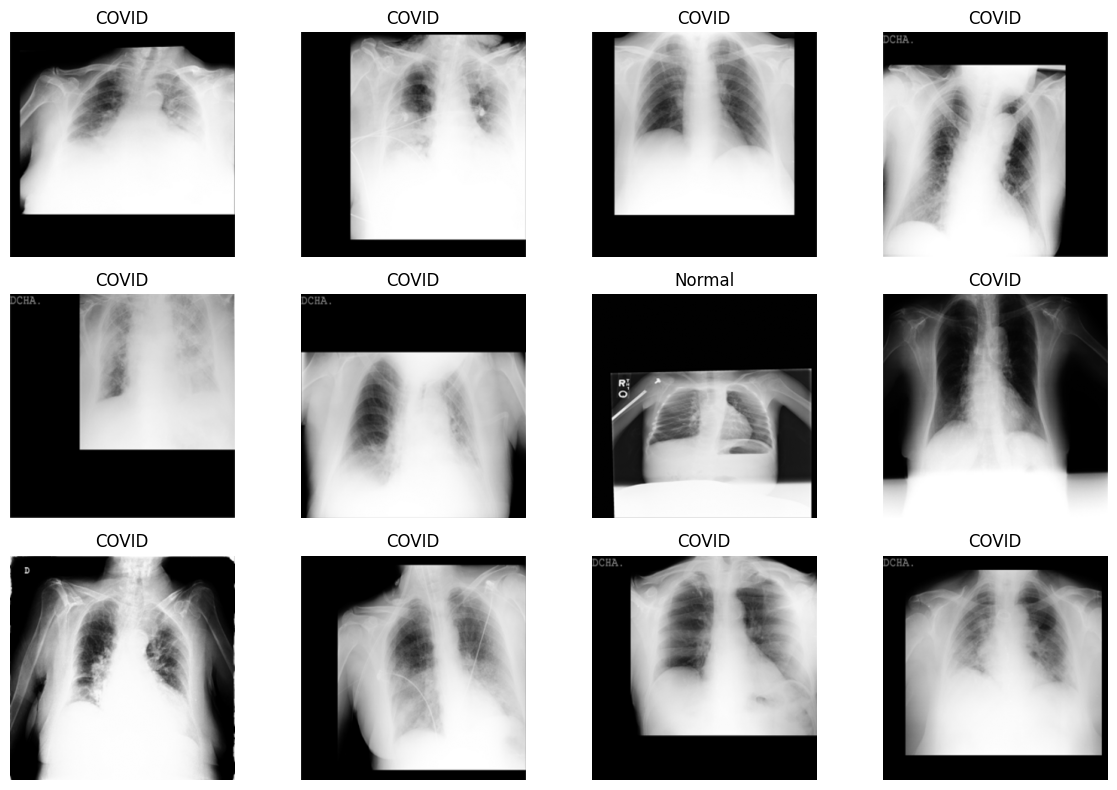

In [32]:
#partie peut-être pas pertinente: TODO : vérifier puis supprimer
print("IMAGES LES PLUS \"NORMALES\"")

normal = df.sort_values("contrast", ascending=False).head(12)

fig, axes = plt.subplots(3,4, figsize=(12,8))

for ax, (_, row) in zip(axes.flat, normal.iterrows()):
    # Utilisation du chemin d'accès complet et correct déjà stocké dans le DataFrame
    img_path = Path(row["filepath"])
    img = Image.open(img_path)

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row['class']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

mean_intensity              contrast           
                 mean        std       mean        std
class                                                 
COVID       139.52121  25.029784  54.647365  14.829089
Normal      129.38980  22.448670  61.559355   9.551679

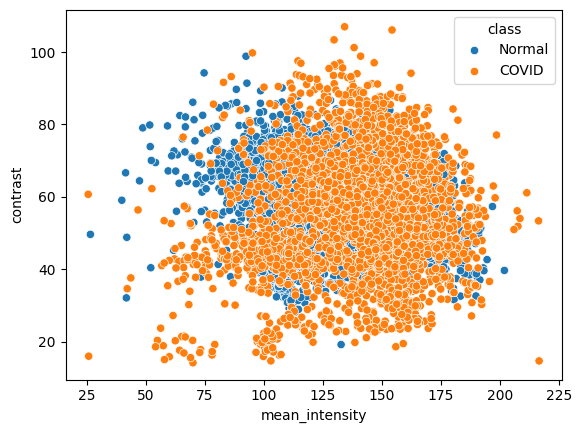

In [33]:
#scatterplot intensite vs contraste + valeurs by class
sns.scatterplot(
    data=df,
    x="mean_intensity",
    y="contrast",
    hue="class"
)

df.groupby("class")[["mean_intensity", "contrast"]].agg(
    ["mean", "std"]
)